Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:10<00:00, 235MB/s]

Found 4434 images belonging to 2 classes.
Found 782 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 137s 867ms/step - accuracy: 0.8496 - loss: 0.3368 - precision: 0.8858 - recall: 0.9156 - val_accuracy: 0.9015 - val_loss: 0.2052 - val_precision: 0.9406 - val_recall: 0.9260 - learning_rate: 1.0000e-04
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 105s 755ms/step - accuracy: 0.9051 - loss: 0.2366 - precision: 0.9336 - recall: 0.9390 - val_accuracy: 0.9143 - val_loss: 0.1962 - val_precision: 0.9656 - val_recall: 0.9174 - learning_rate: 1.0000e-04
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 105s 753ms/step - accuracy: 0.9258 - loss: 0.1819 - precision: 0.9491 - recall: 0.9511 - val_accuracy: 0.9335 - val_loss: 0.

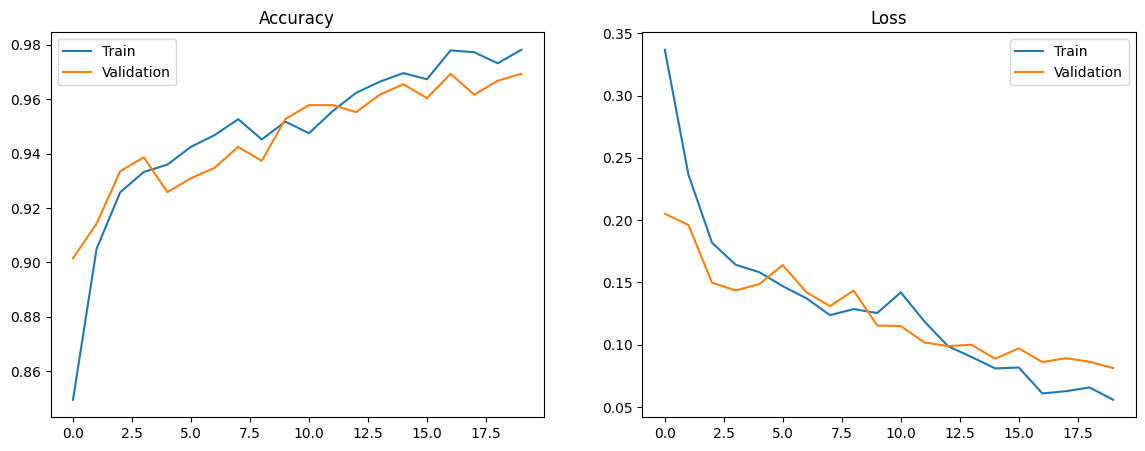

20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 454ms/step


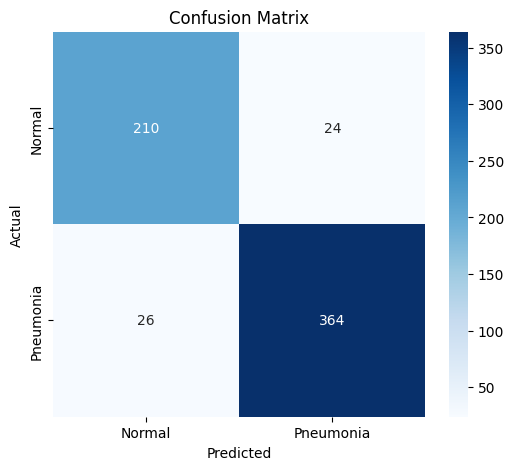


===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.89      0.90      0.89       234
           1       0.94      0.93      0.94       390

    accuracy                           0.92       624
   macro avg       0.91      0.92      0.91       624
weighted avg       0.92      0.92      0.92       624

 ResNet50 Model Saved Successfully


In [ ]:
# ============================================
# 1. KAGGLE DOWNLOAD
# ============================================

from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia --force
!unzip -q -o chest-xray-pneumonia.zip
!rm -rf __MACOSX

# ============================================
# 2. IMPORTS
# ============================================

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ============================================
# 3. PATHS
# ============================================

train_dir = "/content/chest_xray/train"
test_dir  = "/content/chest_xray/test"

IMG_SIZE = 224
BATCH_SIZE = 32

# ============================================
# 4. DATA AUGMENTATION
# ============================================

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    zoom_range=0.3,
    shear_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.15
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# ============================================
# 5. DATA LOADING
# ============================================

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# ============================================
# 6. RESNET50 BASE MODEL
# ============================================

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

# ============================================
# 7. MODEL HEAD
# ============================================

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

# ============================================
# 8. COMPILE
# ============================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

# ============================================
# 9. CALLBACKS
# ============================================

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.5, patience=2),
    ModelCheckpoint("best_resnet50.keras", save_best_only=True)
]

# ============================================
# 10. TRAIN PHASE 1
# ============================================

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks
)

# ============================================
# 11. FINE TUNING
# ============================================

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks
)

# ============================================
# 12. EVALUATION
# ============================================

results = model.evaluate(test_gen)

print("\n===== TEST RESULTS =====")
for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")

# ============================================
# 13. ACCURACY PLOT
# ============================================

acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']

loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, acc)
plt.plot(epochs_range, val_acc)
plt.title("Accuracy")
plt.legend(["Train", "Validation"])

plt.subplot(1,2,2)
plt.plot(epochs_range, loss)
plt.plot(epochs_range, val_loss)
plt.title("Loss")
plt.legend(["Train", "Validation"])

plt.show()

# ============================================
# 14. CONFUSION MATRIX
# ============================================

test_gen.reset()

predictions = model.predict(test_gen)
y_pred = (predictions > 0.5).astype(int).reshape(-1)
y_true = test_gen.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal','Pneumonia'],
    yticklabels=['Normal','Pneumonia']
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ============================================
# 15. CLASSIFICATION REPORT
# ============================================

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_true, y_pred))

# ============================================
# 16. SAVE MODEL
# ============================================

model.save("resnet50_pneumonia_best_1.keras")

print(" ResNet50 Model Saved Successfully")

Model Loaded Successfully ✅
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


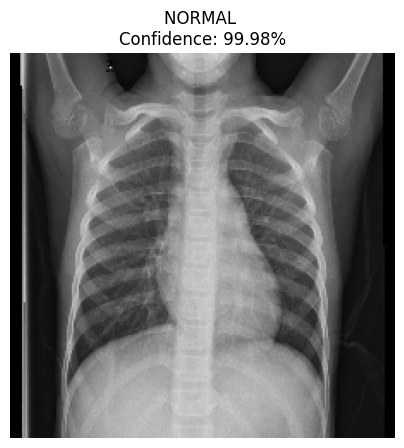

Prediction: NORMAL 
Confidence: 99.98%


In [6]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet import preprocess_input


model = tf.keras.models.load_model(
    "resnet50_pneumonia_best_1.keras",
    compile=False
)

print("Model Loaded Successfully ✅")


# image path
img_path = "/content/NORMAL2-IM-0110-0001.jpeg"



# Load image
img = image.load_img(
    img_path,
    target_size=(224,224)
)

img_array = image.img_to_array(img)

# نفس preprocessing التدريب
img_array = preprocess_input(img_array)

img_array = np.expand_dims(
    img_array,
    axis=0
)


# Prediction
prediction = model.predict(img_array)[0][0]


if prediction > 0.5:
    label = "PNEUMONIA "
    confidence = prediction
else:
    label = "NORMAL "
    confidence = 1-prediction


# show image
plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.title(
    f"{label}\nConfidence: {confidence*100:.2f}%"
)
plt.show()


print("Prediction:", label)
print("Confidence:", f"{confidence*100:.2f}%")

Model Loaded Successfully ✅
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


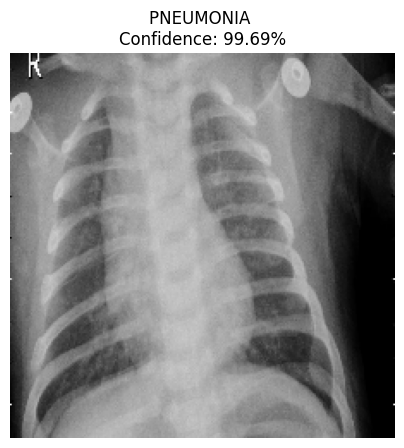

Prediction: PNEUMONIA 
Confidence: 99.69%


In [8]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet import preprocess_input


model = tf.keras.models.load_model(
    "resnet50_pneumonia_best_1.keras",
    compile=False
)

print("Model Loaded Successfully ✅")


# image path
img_path = "/content/person75_virus_136.jpeg"



# Load image
img = image.load_img(
    img_path,
    target_size=(224,224)
)

img_array = image.img_to_array(img)

# نفس preprocessing التدريب
img_array = preprocess_input(img_array)

img_array = np.expand_dims(
    img_array,
    axis=0
)


# Prediction
prediction = model.predict(img_array)[0][0]


if prediction > 0.5:
    label = "PNEUMONIA "
    confidence = prediction
else:
    label = "NORMAL "
    confidence = 1-prediction


# show image
plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.title(
    f"{label}\nConfidence: {confidence*100:.2f}%"
)
plt.show()


print("Prediction:", label)
print("Confidence:", f"{confidence*100:.2f}%")